This notebook runs through elements of the optimized first wedge and the QQ+Sector Dipole dispersion suppressor.

Written by: Inci Karaaslan

Created: 2/22/2026

# Setup

In [1]:
# Important! All of the functions utilized in this notebook unless defined here comes from these two scripts. 
# For more information on the functions, check scan.py and g4beam.py!!
from scan import *
from g4beam import *
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
import numpy as np
import pandas as pd
from tqdm import *
import pickle
import itertools
from tabulate import tabulate
import re

In [2]:
# Make Sure g4bl path is in here -- change the "/home/incik/G4beamline-3.08/bin" with your "G4beamline-3.08/bin" path
import os
os.environ["PATH"] += os.pathsep + "/home/incik/G4beamline-3.08/bin"
import shutil
print(shutil.which("g4bl"))

/home/incik/G4beamline-3.08/bin/g4bl


# Initial distribution

First Wedge Optimization done by Daniel Fu: A Gaussian beam is generated using Mike Syphers' theoretical description of the parameters needed via https://nicadd.niu.edu/~syphers/tutorials/analyzeTrack.html#analyzing-a-distribution.

The parameters of the initial beam are treated as constants, but some things are known about their effects:
- **Transverse emittance**: Should be as low as possible. For this test we use an "optimistic" value of 110 microns.
- **Momentum**: Decreasing this appears to slightly decreases x-emittance.
- **Beta**: Decreasing this decreases the y-emittance growth. There may also be an optimal value for x-emittance.
- **Alpha**: Increasing this decreases the y-emittance growth, but past a certain point increases the x-emittance. I believe 0.7 focuses the beam onto the wedge center with a VD distance of 24 mm.
- **Longitudinal emittance**: Effects not yet tested.
- **Standard deviation of momentum**: Decreasing this decreases the x-emittance.
- **Virtual detector distance**: Almost irrelevant. Should be more than 3x the length of the wedge to ensure accurate measurements.

In [3]:
t_emit = 0.145  # mm
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 0.7     # dimensionless
l_emit = 1      # mm
pz_std = 1    # MeV/c
vd_dist = 24    # mm

pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=20000)
pre_w1["PDGid"] = -13
print_all_params(pre_w1)

-----------------------------
Twiss parameters for X
emit  = 0.14504122316332527 mm
beta  = 0.029954080477996976 m
gamma = 49.58043272669052 1/m
alpha = 0.6965172446028907
D     = -0.0021617323669251443 m
D'    = 0.07836714306860831

Twiss parameters for Y
emit  = 0.14405163065179982 mm
beta  = 0.02996321823868747 m
gamma = 49.25242450092874 1/m
alpha = 0.6897544085439437
D     = -0.002040641557643204 m
D'    = 0.0715941679121762

Z-emittance:  1.2600068972382008 mm
Z std: 154.82822916717674 mm
p std: 1.00291418460002 MeV/c
Mean momentum: 99.99138212980912 MeV/c
-----------------------------


In [4]:
write_trackfile(pre_w1, "particles_before_firstwedge.txt")

# First wedge -- Run Optimized Value

In [5]:
post_w1 =  run_g4beam(pre_w1, "G4_FinalCooling_auto.g4bl")
print_all_params(post_w1)

-----------------------------
Twiss parameters for X
emit  = 0.045668189276504456 mm
beta  = 0.03544816817168521 m
gamma = 188.72073479803333 1/m
alpha = -2.385331076518455
D     = 0.02036710686872235 m
D'    = -0.025950979054499036

Twiss parameters for Y
emit  = 0.15026202926536628 mm
beta  = 0.025548650066398906 m
gamma = 57.213282796639625 1/m
alpha = -0.6795013916992859
D     = -9.323628352397193e-05 m
D'    = -0.006450456358630124

Z-emittance:  6.408423553495421 mm
Z std: 143.43035493312533 mm
p std: 7.161122108571713 MeV/c
Mean momentum: 87.9298316309411 MeV/c
-----------------------------


In [6]:
# Write the wedge output into a file
write_trackfile(post_w1, "particles_after_firstwedge.txt")

In [7]:
# Optimized G4_FinalCooling_auto.g4bl parameters
w1_length = 7.08 #mm
w1_angle = 47.2 #deg
offset = w1_length / (math.tan(w1_angle * math.pi / 180) * 2)
base_length = 24
abswidth = 100
parameters = dict(
        abshalfangle3=str(w1_angle),
        absoffset3=str(offset),
        abshgt=str(offset * base_length / w1_length + 0.1),
        absLEN3=str(base_length)
    )
L_centerline = float(parameters['absLEN3']) + 1
print("Where to put the next element: " + str(L_centerline) + "mm")

Where to put the next element: 25.0mm


In [8]:
# If particles_after isn't updated with Z = 0, so if we want to use the resulting distribution as the initial distribution
# for each of the files, we must set the particle distribution we get after to have a z of 0.
def convertZ(input_file, output_file, set_to=0):
    event_id_counter = 1
    with open(input_file, "r") as infile, open(output_file, "w") as outfile:
        for line in infile:
            # Skip header lines (those starting with #)
            if line.strip().startswith("#"):
                outfile.write(line)
                continue

            # Split the line into columns
            parts = line.strip().split()
            if len(parts) >= 12:
                parts[2] = str(set_to)  # Set the 3rd column (z) to 0
                # Replace event ID (assuming it's the 9th column, zero-based index 8)
                # Adjust if your event ID is in a different column
                parts[8] = str(event_id_counter)
                event_id_counter += 1
                new_line = " ".join(parts)
                outfile.write(new_line + "\n")
            else:
                # Handle lines that don't match expected format
                outfile.write(line)
    print(f"Updated file saved as '{output_file}'")
    os.remove(input_file)
    return None

In [9]:
convertZ("particles_after_firstwedge.txt", "particles_after_firstwedgeupt.txt", set_to=0.0)

Updated file saved as 'particles_after_firstwedgeupt.txt'


# Dispersion correction optimized

The main goal is to have $D_x \approx 0$ up to 1e-5 m while keeping $\beta_x$ relatively periodic and about at the same value.

In [10]:
# Write values to the prepared G4BL template
def write_input_from_template(template_path, replacements, out_path):
    with open(template_path, 'r') as f:
        txt = f.read()
    try:
        txt = txt.format(**replacements)
    except KeyError as e:
        raise RuntimeError(f"Template substitution failed; missing placeholder: {e}")
    with open(out_path, 'w') as f:
        f.write(txt)

In [11]:
def clean_field_files():
    for f in ["field_cellBSec.dat", "field_cellQ2.dat"]:
        if os.path.exists(f):
            os.remove(f)

In [12]:
# Beta and Dispersion we have from after the wedge:
x0_params, y0_params, _ = calc_all_params(post_w1)
beta_x_ref= x0_params[1]; beta_y_ref= y0_params[1]
print(r"$\beta_x$: " + str(beta_x_ref), r"$\beta_y$: " + str(beta_y_ref))
print("D_x: " + str(x0_params[4]), "D_y: " + str(y0_params[4]))
print("Emittance: " + str(x0_params[0]))

$\beta_x$: 0.03544816817168521 $\beta_y$: 0.025548650066398906
D_x: 0.02036710686872235 D_y: -9.323628352397193e-05
Emittance: 0.045668189276504456


In [13]:
print_all_params(post_w1)

-----------------------------
Twiss parameters for X
emit  = 0.045668189276504456 mm
beta  = 0.03544816817168521 m
gamma = 188.72073479803333 1/m
alpha = -2.385331076518455
D     = 0.02036710686872235 m
D'    = -0.025950979054499036

Twiss parameters for Y
emit  = 0.15026202926536628 mm
beta  = 0.025548650066398906 m
gamma = 57.213282796639625 1/m
alpha = -0.6795013916992859
D     = -9.323628352397193e-05 m
D'    = -0.006450456358630124

Z-emittance:  6.408423553495421 mm
Z std: 143.43035493312533 mm
p std: 7.161122108571713 MeV/c
Mean momentum: 87.9298316309411 MeV/c
-----------------------------


In [14]:
write_trackfile(post_w1, "particles_after_firstwedge.txt")

In [222]:
def beam_size(beta, eps, n_sigma=15):
    """
    Compute full beam width/height in mm for given beta (m) and emittance (mm·mrad)
    """
    sigma = np.sqrt(beta * eps * 1e3)  # convert sigma (mm) = sqrt(m * 1e3 * mm)
    return n_sigma * sigma

radius_q = max(
    np.percentile(np.abs(post_w1["x"]), 99.9),
    np.percentile(np.abs(post_w1["y"]), 99.9)
    ) * 5.0
B_pole_max = 5.0
gradBound = B_pole_max / (radius_q*1e-3)
print(f"Max gradient bound for quads : ({-gradBound}, {gradBound}) ")

Max gradient bound for quads : (-122.1039222306116, 122.1039222306116) 


In [223]:
def run_two_quadrupoles(df, Q1_gradient, Q2_gradient, Drift1_length, Q1_z, Q1_radius=radius_q, Q2_radius=radius_q, Q1_length=100, Q2_length=100, thickness=5):
    """
    Runs G4BL with two sequential quadrupoles.
    """
    Drift1_width=2*max(Q1_radius,Q2_radius)
    Drift1_height=2*max(Q1_radius,Q2_radius)
    # Q1_z : f"{L_centerline + (Q1_length / 2):.12f}",
    params = {
    "Q1_z": f"{Q1_z + (Q1_length / 2):.12f}",
    "Q1_length": f"{Q1_length:.12f}",
    "Q1_gradient": f"{Q1_gradient:.12f}",
    "radius_q1": f"{Q1_radius:.12f}",
    "radius_q2": f"{Q2_radius:.12f}",
    "thickness": f"{thickness:.12f}",
    "Q1_end": f"{Q1_z + Q1_length:.12f}",
    "Q2_length":f"{Q2_length:.12f}",
    "Q2_gradient": f"{Q2_gradient:.12f}",
    "Drift1_length": f"{Drift1_length:.12f}",
    "Drift1_z": f"{Q1_z + Q1_length + (Drift1_length / 2):.12f}",
    "Drift1_width": f"{Drift1_width:.12f}", 
    "Drift1_height":f"{Drift1_height:.12f}",
    "D1_end": f"{Q1_z + Q1_length + Drift1_length:.12f}",
    "Q2_z": f"{Q1_z + Q1_length + Drift1_length + Q2_length/2:.12f}",
    "Q2_end": f"{Q1_z + Q1_length + Drift1_length + Q2_length:.12f}",
    }

    print("PARAMS PASSED TO TEMPLATE:")
    for k, v in params.items():
        print(k, "=", v)
    write_input_from_template("G4_FinalCooling_dispsup_Q2.g4bl", params, "G4_FinalCooling_dispsup_Q2_run.g4bl")
    
    # Run this file
    res = run_g4beam(df, "G4_FinalCooling_dispsup_Q2_run.g4bl")

    if res is None or len(res) < 10:
        print("G4BL run failed or empty. Check template and parameters.")
        return None
    return res

In [224]:
history = []
def optimize_qq_drift_safe(x, df, beta_x_ref, beta_y_ref, w_disp=1000, w_beta=10000.0):
    """
    Optimizer wrapper with:
    - Survival-aware penalty
    - Full diagnostics
    """

    q1_gradient, q2_gradient, d1_length, q1_z = x
    print("\nTRYING x =", x)

    try:
        result = run_two_quadrupoles(df, q1_gradient, q2_gradient, d1_length, q1_z)
        # Check where particles are dying
        print(f"x range: {result['x'].min():.1f} to {result['x'].max():.1f} mm")
        print(f"y range: {result['y'].min():.1f} to {result['y'].max():.1f} mm")
        print(f"Pz range: {result['Pz'].min():.1f} to {result['Pz'].max():.1f} MeV/c")
        print(f"Input: {2000}, Output: {len(result)}")
    except Exception as e:
        print("EXCEPTION in run_two_quadrupoles:", e)
        return 1e6

    if result is None or len(result) == 0:
        print("No particles survived")
        return 1e6

    # Compute survival fraction
    N0 = 2000 #len(df)
    Ns = len(result)

    survival = Ns / N0
    print(f"Particles survived: {Ns}/{N0} → survival={survival:.3f}")

    if survival < 0.90:
        print(f"Survival too low, returning penalty")
        return 1e7 + 1e6 * (0.90 - survival)

    # Compute optics parameters
    try:
        x_params, y_params, _ = calc_all_params(result)
    except Exception as e:
        print("EXCEPTION in calc_all_params:", e)
        return 1e5
    

    Dx = x_params[4]
    Dxp = x_params[5]
    beta_x = x_params[1]
    beta_y = y_params[1]
    ex = x_params[0]
    ey = y_params[0]
    
    eps = 1e-4
    
    disp_penalty =  (np.abs(Dx) / 1e-4)**2 + (np.abs(Dxp) / 1e-2)**2
    beta_penalty = ((beta_x - beta_x_ref) / beta_x_ref)**2 + ((beta_y - beta_y_ref) / beta_y_ref)**2
    # Log-scaled optics loss
    optics_loss = w_beta * np.log(beta_penalty**2 + eps)
    disp_loss = w_disp * np.log(disp_penalty + eps)

    # Total objective
    val = optics_loss + disp_loss

    print(f"OBJECTIVE = {val:.6f}, Dx={Dx:.6f}, Dxp={Dxp:.6f}, beta_penalty={beta_penalty:.6f}, emit={ex:.6f}")
    history.append({
    "Q1_G": q1_gradient,
    "Q2_G": q2_gradient,
    "Drift1_L": d1_length,
    "Q1_z": q1_z,
    "Dx": Dx,
    "beta_x": beta_x,
    "beta_y": beta_y,
    "survival": survival,
    "objective": val})
    return val

In [217]:
"""from skopt import gp_minimize"""
x0 = [-61.97363495,  69.06470063,   20.2317333,  25.        ]# [ -9.00758863, 11.56562394, 19.697143, L_centerline*2] #[-9.00758863, 11.56562394,  40.41906277, L_centerline] # [ -9.00758863, 11.56562394, 19.697143, L_centerline]
# [-61.97363495  69.06470063   2.02317333  25.        ] BEST transmission
# Physical bounds
bounds = np.array([
    [-gradBound, gradBound],      # Q1_gradient
    [-gradBound, gradBound],    # Q2_gradient
    [10, 3000],    # Drift1_length
    [L_centerline, L_centerline*100]
])

res = scipy.optimize.minimize(
    optimize_qq_drift_safe, x0,
    args=(post_w1, beta_x_ref, beta_y_ref),
    method="Nelder-Mead", bounds=bounds,
    options={"xatol":1e-4, "fatol":1e-6, "maxiter":500}
)
"""res = gp_minimize(
    lambda x: optimize_qq_drift_safe(x, post_w1, beta_x_ref, beta_y_ref),
    bounds,
    x0=[x0],   # your initial guess here (must be a list of lists)
    n_calls=50,
    n_initial_points=10,
    random_state=42)"""
print("Optimal parameters:", res.x)


TRYING x = [-61.97363495  69.06470063  20.2317333   25.        ]
PARAMS PASSED TO TEMPLATE:
Q1_z = 75.000000000000
Q1_length = 100.000000000000
Q1_gradient = -61.973634950000
radius_q1 = 81.897451100002
radius_q2 = 81.897451100002
thickness = 5.000000000000
Q1_end = 125.000000000000
Q2_length = 100.000000000000
Q2_gradient = 69.064700630000
Drift1_length = 20.231733300000
Drift1_z = 135.115866650000
Drift1_width = 163.794902200005
Drift1_height = 163.794902200005
D1_end = 145.231733300000
Q2_z = 195.231733300000
Q2_end = 245.231733300000


KeyboardInterrupt: 

In [225]:
resa = [-63.59862651,  84.90171809,   2.73282227,  25.        ]
df_opt_q = run_two_quadrupoles(post_w1, Q1_gradient=resa[0], Q2_gradient=resa[1], Drift1_length=resa[2], Q1_z=resa[3])
print(df_opt_q)
write_trackfile(df_opt_q, "particles_after_q2.txt")

PARAMS PASSED TO TEMPLATE:
Q1_z = 75.000000000000
Q1_length = 100.000000000000
Q1_gradient = -63.598626510000
radius_q1 = 40.948725550001
radius_q2 = 40.948725550001
thickness = 5.000000000000
Q1_end = 125.000000000000
Q2_length = 100.000000000000
Q2_gradient = 84.901718090000
Drift1_length = 2.732822270000
Drift1_z = 126.366411135000
Drift1_width = 81.897451100002
Drift1_height = 81.897451100002
D1_end = 127.732822270000
Q2_z = 177.732822270000
Q2_end = 227.732822270000
             x         y        z        Px        Py       Pz         t  \
0     -4.54727   1.26011  227.733   9.60816   1.96906  90.8049  0.708867   
1    -10.96140 -15.93250  227.733  24.03730 -22.07830  85.7786  1.747540   
2      1.84283  12.58580  227.733  -3.93263  16.29530  87.3412  1.280030   
3     -8.53056  10.38990  227.733  19.95510  13.74450  85.4135  1.073440   
4     -6.54232  -3.63203  227.733  14.27930  -5.88823  89.6220 -0.399582   
...        ...       ...      ...       ...       ...      ...      

In [226]:
x_params_q, y_params_q, z_emit_q = calc_all_params(df_opt_q)
print("Dx, Dy =", x_params_q[4], y_params_q[4])
b_dict = {"Beta_x" : x_params_q[1], "Beta_y" : y_params_q[1]}
print(b_dict)
with open("particles_after_q2.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = len(post_w1)
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print("Transmission = ", trans_percent)

Dx, Dy = 0.0077024699197944515 0.002060902171879492
{'Beta_x': np.float64(0.15151711748563673), 'Beta_y': np.float64(0.8679880200917737)}
9408
Transmission =  78.4


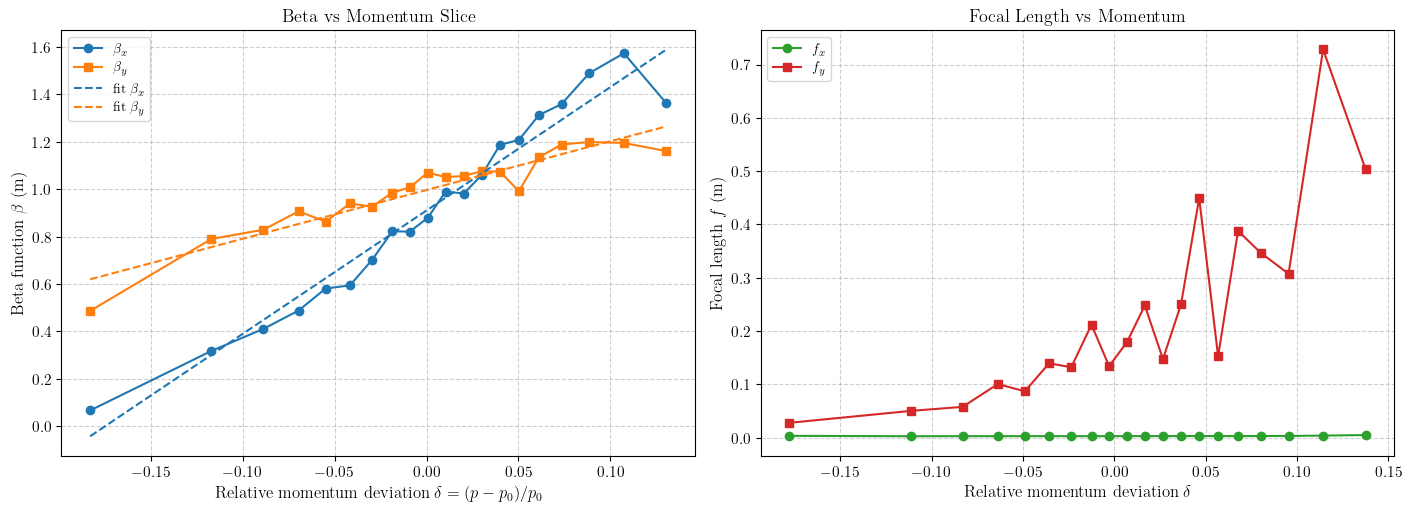

In [227]:
import numpy as np
import matplotlib.pyplot as plt

# --- Enable LaTeX rendering globally ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

# --- tune vs momentum ---
deltas, bx, by = tune_vs_momentum(df_opt_q)

# Linear fits (chromaticity proxy)
coef_x = np.polyfit(deltas, bx, 1)
coef_y = np.polyfit(deltas, by, 1)
delta_fit = np.linspace(deltas.min(), deltas.max(), 200)

# --- focal length vs momentum ---
deltas_f, fx, fy = focal_length_vs_momentum(post_w1, df_opt_q)
fx_m = fx / 1000
fy_m = fy / 1000

# --- create figure ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")

# --- Beta function plot (connected dots) ---
axes[0].plot(deltas, bx, 'o-', label=r'$\beta_x$', markersize=6, color='tab:blue', lw=1.5)
axes[0].plot(deltas, by, 's-', label=r'$\beta_y$', markersize=6, color='tab:orange', lw=1.5)
axes[0].plot(delta_fit, np.polyval(coef_x, delta_fit), '--', color='tab:blue', lw=1.5, label=r'fit $\beta_x$')
axes[0].plot(delta_fit, np.polyval(coef_y, delta_fit), '--', color='tab:orange', lw=1.5, label=r'fit $\beta_y$')

axes[0].set_xlabel(r'Relative momentum deviation $\delta = (p - p_0)/p_0$')
axes[0].set_ylabel(r'Beta function $\beta$ (m)')
axes[0].set_title(r'Beta vs Momentum Slice')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# --- Focal length plot (connected dots) ---
axes[1].plot(deltas_f, fx_m, 'o-', label=r'$f_x$', markersize=6, color='tab:green', lw=1.5)
axes[1].plot(deltas_f, fy_m, 's-', label=r'$f_y$', markersize=6, color='tab:red', lw=1.5)

axes[1].set_xlabel(r'Relative momentum deviation $\delta$')
axes[1].set_ylabel(r'Focal length $f$ (m)')
axes[1].set_title(r'Focal Length vs Momentum')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.show()

In [228]:
x_params_q, y_params_q, z_emit_q = calc_all_params(df_opt_q)
print("Dx, Dxp =", x_params_q[4], x_params_q[5])
b_dict = {"Beta_x" : x_params_q[1], "Beta_y" : y_params_q[1]}
print(b_dict)
print("E_x = ", x_params_q[0], "E_y = ", y_params_q[0])
with open("particles_after_q2.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 12000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print("Transmission = ", trans_percent)

Dx, Dxp = 0.0077024699197944515 -0.3620141144589103
{'Beta_x': np.float64(0.15151711748563673), 'Beta_y': np.float64(0.8679880200917737)}
E_x =  0.5987252626087141 E_y =  0.1640989801458123
9408
Transmission =  78.4


In [229]:
print_all_params(df_opt_q)

-----------------------------
Twiss parameters for X
emit  = 0.5987252626087141 mm
beta  = 0.15151711748563673 m
gamma = 121.22462761145624 1/m
alpha = 4.167445997725415
D     = 0.0077024699197944515 m
D'    = -0.3620141144589103

Twiss parameters for Y
emit  = 0.1640989801458123 mm
beta  = 0.8679880200917737 m
gamma = 186.8747644085248 1/m
alpha = -12.696655337689219
D     = 0.002060902171879492 m
D'    = 0.029657398019118566

Z-emittance:  7.702036996334945 mm
Z std: 144.75480628462086 mm
p std: 6.837346411232872 MeV/c
Mean momentum: 88.48240772395101 MeV/c
-----------------------------


In [230]:
if os.path.exists("particles_after_q2upt.txt"):
    os.remove("particles_after_q2upt.txt")
convertZ("particles_after_q2.txt", "particles_after_q2upt.txt", set_to=0.0)
df_opt_q_zero = read_trackfile("particles_after_q2upt.txt")

Updated file saved as 'particles_after_q2upt.txt'


In [231]:
# Height and Width of B field
size_b = max(
    np.percentile(np.abs(df_opt_q["x"]), 99.9),
    np.percentile(np.abs(df_opt_q["y"]), 99.9)
    ) * 5.0
print("So the B radius: " + str(size_b) + " mm")

So the B radius: 190.74947450000064 mm


In [247]:
def run_dipole(df, B_field, B_angle, B_radius, B_z, B_thickness=50, B_height=100):
    if os.path.exists("field_cellB.dat"):
        os.remove("field_cellB.dat")
    """Run dipole simulation with given parameters."""
    params = {
        "B1_field": B_field,
        "B1_angle": B_angle,
        "B1_radius": B_radius,
        "B1_z": B_z,
        "B1_z_end": B_z + B_radius * B_angle * math.pi/180,
        "B1_x_end": 0.0,
        "B1_thickness": B_thickness,
        "B1_height": B_height
    }
    write_input_from_template("G4_FinalCooling_dispsup_Bn.g4bl", params, "G4_FinalCooling_dispsup_Bn_run.g4bl")
    # Run G4Beamline
    df_out = run_g4beam(df, "G4_FinalCooling_dispsup_Bn_run.g4bl")

    return df_out

In [248]:
def optimize_dipole(x, df_in, beta_x_ref, beta_y_ref, 
                    w_disp=100.0, w_beta=1.0, 
                    survival_threshold=0.90):
    """
    Optimize dipole parameters using G4Beamline simulations.

    Parameters
    ----------
    x : array-like
        Dipole parameters: [B_field, B_angle_deg, B_radius]
    df_in : pandas.DataFrame
        Input particle distribution
    beta_x_ref, beta_y_ref : float
        Target beta functions
    w_disp, w_beta : float
        Weights for cost function
    survival_threshold : float
        Minimum fraction of particles that must survive

    Returns
    -------
    float
        Objective function value (smaller is better)
    """
    # Unpack parameters
    B_field, B_angle, B_radius, B_z = x
    B_thickness = 50.0
    B_height = 100.0

    # Run dipole simulation
    result = run_dipole(df_in, B_field, B_angle, B_radius, B_z)
    if result is None or len(result) == 0:
        # no particles survived, penalize heavily
        return 1e6

    # Survival fraction
    N0 = len(df_in)
    Ns = len(result)
    survival_frac = Ns / N0
    print(f"Particles survived: {Ns}/{N0} → survival={survival_frac:.3f}")
    if survival_frac < survival_threshold:
        penalty = 1e12 + 1e9 * (survival_threshold - survival_frac)
        print(f"Survival below threshold, returning penalty {penalty}")
        return penalty

    x_params_d, y_params_d, _ = calc_all_params(result)
    Dx   = x_params_d[4]
    Dxp  = x_params_d[5]
    beta_x = x_params_d[1]
    beta_y = y_params_d[1]

    beta_x_max = 0.9    
    beta_y_max = 0.9

    disp_penalty = (np.abs(Dx) / 1e-4)**2 # + 100 * (np.abs(Dxp) / 1e-3)**2
    beta_penalty = (max(0, beta_x - beta_x_max) / beta_x_max)**2 \
                + (max(0, beta_y - beta_y_max) / beta_y_max)**2

    val = w_disp * disp_penalty + w_beta * beta_penalty
    print(f"Objective = {val:.3f}, Survival = {survival_frac:.3f}, Dx = {Dx:.6f}, Dxp = {Dxp:.4f}, beta_x = {beta_x:.3f}, beta_y = {beta_y:.3f}")
    return val

In [234]:
start = time.time()
# Run optimization [-3.00000000e+00,  1.37663546e+00,  1.87185672e+03,  1.55732126e+01] [3, 1.41, 950.9, 0.5]
optim_result = minimize(optimize_dipole,[-3.00000000e+00,  1.37663546e+00,  1.87185672e+03,  1.55732126e+01], args=(df_opt_q_zero, b_dict["Beta_x"], b_dict["Beta_y"]), method="Nelder-Mead", bounds=((-3.0, 3.0), (1.0, 10.0), (size_b, size_b*1000), (0.5, 1000.0)), options=dict(fatol=1e-6))

# Get results
B_field, B_angle, B_radius, B_z = optim_result.x
print(f"Field = {B_field:.2f} T \nAngle = {B_angle:.2f} deg\nRadius = {B_radius:.1f} mm\nSpacing = {B_z:.1f} mm")
print("Time spent:", time.time()-start)

iter value
Particles survived: 1806/2000 → survival=0.903
Objective = 1672086.491, Survival = 0.903, Dx = -0.012931, Dxp = -0.4306, beta_x = 0.124, beta_y = 2.247
Particles survived: 1806/2000 → survival=0.903
Objective = 1672086.491, Survival = 0.903, Dx = -0.012931, Dxp = -0.4306, beta_x = 0.124, beta_y = 2.247
Particles survived: 1774/2000 → survival=0.887
Survival below threshold, returning penalty 1000013000000.0
Particles survived: 1773/2000 → survival=0.886
Survival below threshold, returning penalty 1000013500000.0
Particles survived: 1801/2000 → survival=0.900
Objective = 1488643.065, Survival = 0.900, Dx = -0.012201, Dxp = -0.4220, beta_x = 0.129, beta_y = 2.263
Particles survived: 1821/2000 → survival=0.910
Objective = 1863064.472, Survival = 0.910, Dx = -0.013649, Dxp = -0.4460, beta_x = 0.118, beta_y = 2.242
Particles survived: 1839/2000 → survival=0.919
Objective = 2128056.956, Survival = 0.919, Dx = -0.014588, Dxp = -0.4647, beta_x = 0.109, beta_y = 2.167
Particles survi

KeyboardInterrupt: 

In [50]:
# optim_result.x : [  1.4144313 ,   2.01819995, 529.21704345,   0.99182192]

array([  1.4144313 ,   2.01819995, 529.21704345,   0.99182192])

In [249]:
res = [3, 1.41, 950.9, 0.5]
opt_params = {
        "B1_field": optim_result.x[0],
        "B1_angle": optim_result.x[1],
        "B1_radius": optim_result.x[2],
        "B1_z": optim_result.x[3],
        "B1_z_end": optim_result.x[3] + optim_result.x[2] * optim_result.x[1] * math.pi/180,
        "B1_x_end": 0.0,
        "B1_thickness": 50,
        "B1_height": 100,
    }
if os.path.exists("field_cellB.dat"):
    os.remove("field_cellB.dat")
write_input_from_template("G4_FinalCooling_dispsup_Bn.g4bl", opt_params, "G4_FinalCooling_dispsup_Bn_opt2.g4bl")
df_dip = run_dipole(df_opt_q_zero,  res[0], res[1], res[2], res[3])

In [250]:
write_trackfile(df_dip, "particles_after_b.txt")

In [251]:
if os.path.exists("particles_after_bupt.txt"):
    os.remove("particles_after_bupt.txt")
convertZ("particles_after_b.txt",  "particles_after_bupt.txt")

x_params_dip, y_params_dip, z_emit_dip = calc_all_params(cut_outliers(df_dip, sigma=4))
D_dict_dip = {"D_x": x_params_dip[4], "D'_x": x_params_dip[5], "D_y": y_params_dip[4], "D'_y": y_params_dip[5]}
b_dict_dip = {"Beta_x": x_params_dip[1], "Beta_y": y_params_dip[1]}
print(D_dict_dip, r"Epsilon_z: "+str(z_emit_dip), b_dict_dip)

Updated file saved as 'particles_after_bupt.txt'
{'D_x': np.float64(0.0023382524791230814), "D'_x": np.float64(-0.18373022836881156), 'D_y': np.float64(0.0011586143677746496), "D'_y": np.float64(0.011682805148478572)} Epsilon_z: 10.259667007591954 {'Beta_x': np.float64(0.013352452861984021), 'Beta_y': np.float64(1.4827277352400496)}


In [252]:
with open("particles_after_bupt.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 12000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print("Transmission = ", trans_percent)

9353
Transmission =  77.94166666666666


In [239]:
df_dip_zero = read_trackfile("particles_after_bupt.txt")

In [276]:
# Sigma cut for phase space -- contribution for the cooling is just 1sigma -- dispersion calculation, useful particles can be in 1 sigma, makes the statement a bit more clear, how do we treat the tail
# 3 sigma cut, 5 sigma cut, dispersion include non-linear tail effect. Increase actual dispersion. In the future we take into account this tail transmission 
print_all_params(df_dip)

-----------------------------
Twiss parameters for X
emit  = 0.7357954201835089 mm
beta  = 0.013284486027498528 m
gamma = 96.52906036998382 1/m
alpha = 0.5313557694545266
D     = 0.0036593618648361062 m
D'    = -0.13369046452511932

Twiss parameters for Y
emit  = 0.18340398361405713 mm
beta  = 1.4671587779645905 m
gamma = 161.63172999644198 1/m
alpha = -15.366828282436245
D     = 0.0016430401866862519 m
D'    = 0.01660837492288606

Z-emittance:  10.544137066789117 mm
Z std: 145.05865469755463 mm
p std: 6.819410063972015 MeV/c
Mean momentum: 88.49520110585246 MeV/c
-----------------------------


In [241]:
post_w1_zero = read_trackfile("particles_after_firstwedgeupt.txt")

In [295]:
df_dip_centered = df_dip.copy()
df_dip_centered["x"]  -= np.mean(df_dip["x"])
df_dip_centered["Px"] -= np.mean(df_dip["Px"])
df_dip_centered["y"]  -= np.mean(df_dip["y"])
df_dip_centered["Py"] -= np.mean(df_dip["Py"])


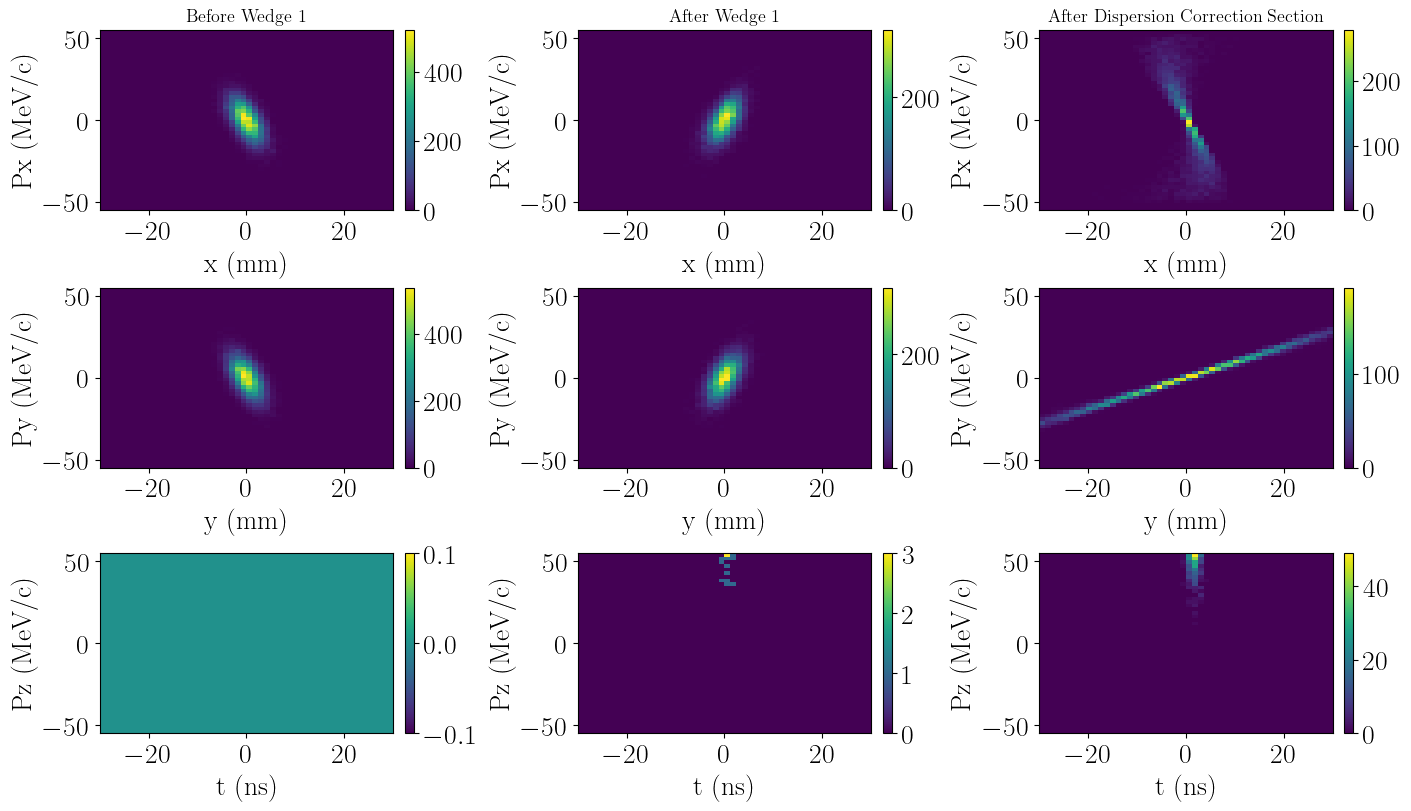

In [300]:
import matplotlib.pyplot as plt

# --- Plot setup ---
PLOT_TARGETS = [pre_w1, post_w1, df_dip_centered]
PLOT_TITLES  = ["Before Wedge 1", "After Wedge 1", "After Dispersion Correction Section"]
PLOT_AXES    = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS  = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
# Histogram ranges: first 2 for T (x,y), last 1 for L (t)
HIST_RANGES  = [[-30, 30, -55, 55], [-30, 30, -55, 55], [-30, 30, -55, 55]]

# LaTeX-friendly fonts
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "axes.labelsize": 20,
    "axes.titlesize": 30,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

fig, axes = plt.subplots(nrows=len(PLOT_AXES), ncols=len(PLOT_TARGETS), figsize=(14, 8), layout="constrained")

for col, df in enumerate(PLOT_TARGETS):
    axes[0][col].set_title(PLOT_TITLES[col], fontsize=13)
    for row, ((xvar, yvar), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[row][col]
        # Select ranges: last row has different ranges
        if row == 2:
            xlim, ylim = HIST_RANGES[col][0:2], HIST_RANGES[col][2:4]
        else:
            xlim, ylim = HIST_RANGES[col][0:2], HIST_RANGES[col][2:4]
        h = ax.hist2d(df[xvar], df[yvar], bins=50, range=[xlim, ylim], cmap="viridis")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        fig.colorbar(h[3], ax=ax, orientation='vertical', fraction=0.045, pad=0.04)

plt.show()

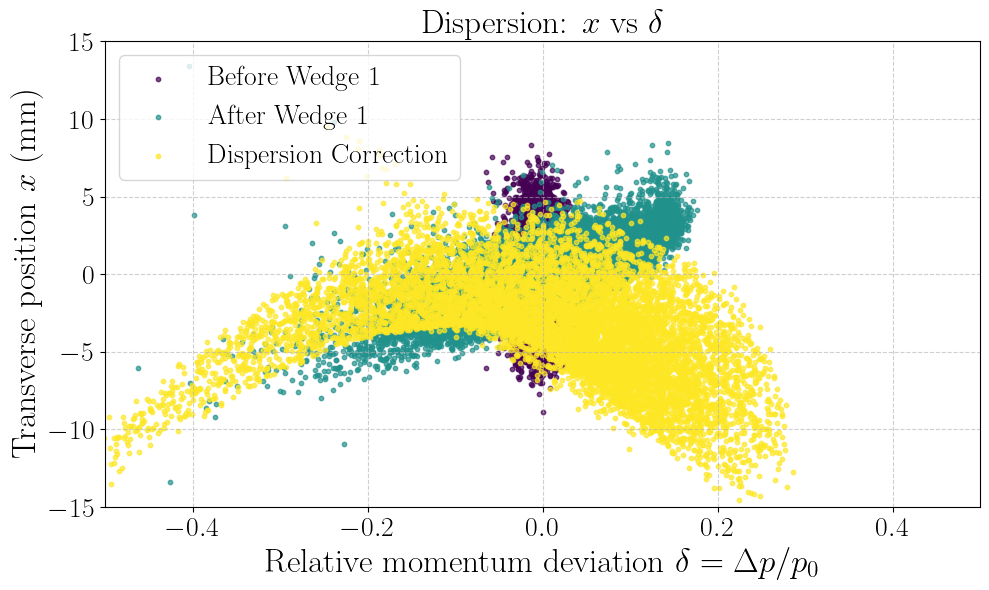

In [292]:
import matplotlib.pyplot as plt
import numpy as np

dfs = [pre_w1, post_w1, df_dip]
titles = [
    "Before Wedge 1",
    "After Wedge 1",
    "Dispersion Correction"
]

# LaTeX-friendly fonts
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "axes.labelsize": 24,
    "axes.titlesize": 24,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

plt.figure(figsize=(10,6))

# Viridis colormap
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(dfs)))

for df, title, c in zip(dfs, titles, colors):
    # Compute relative momentum deviation δ = Δp/p
    p0 = df["Pz"].mean()
    delta = (df["Pz"] - p0) / p0
    x = df["x"]

    # Scatter plot with viridis color
    plt.scatter(delta, x, s=10, alpha=0.7, label=title, color=c)

plt.xlabel(r"Relative momentum deviation $\delta = \Delta p / p_0$")
plt.ylabel(r"Transverse position $x$ (mm)")
plt.title(r"Dispersion: $x$ vs $\delta$")
plt.xlim(-0.5, 0.5)
plt.ylim(-15,15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [261]:
with open("particles_after_bupt.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 2000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print(trans_percent)

9353
467.65


In [269]:
import re

def parse_magnets_from_g4bl(filename):

    magnet_colors = {
        "Q1": "#6699FF",
        "Drift1": "#BBBBBB",
        "Q2": "#6699FF",
        "B1": "#FFAA33"
    }

    regions = []

    with open(filename) as f:
        text = f.read()

    # ----------------------------
    # Find quadrupoles
    # ----------------------------
    quad_pattern = r"genericquad\s+(\w+).*?fieldLength\s*=\s*([-+]?\d*\.?\d+)"
    quads = re.findall(quad_pattern, text, re.DOTALL)

    # ----------------------------
    # Find dipoles (angle * radius)
    # ----------------------------
    dipole_pattern = (
        r"genericsectorbend\s+(\w+).*?"
        r"angle\s*=\s*([-+]?\d*\.?\d+).*?"
        r"fieldCenterRadius\s*=\s*([-+]?\d*\.?\d+)"
    )
    dipoles = re.findall(dipole_pattern, text, re.DOTALL)

    # Build length dictionary
    magnet_lengths = {}

    for name, length in quads:
        magnet_lengths[name] = float(length)
        
    for name, angle, radius in dipoles:
        magnet_lengths[name] = float(math.radians(float(angle))) * float(radius)

        print(float(math.radians(float(angle))) * float(radius))
    
    # ----------------------------
    # Find placements
    # ----------------------------
    place_pattern = r"place\s+(\w+)\s+z\s*=\s*([-+]?\d*\.?\d+)"
    placements = re.findall(place_pattern, text)

    magnet_positions = {name: float(z) for name, z in placements}

    # ----------------------------
    # Build regions
    # ----------------------------
    for name in magnet_positions:
        if name in magnet_lengths and name in magnet_colors:

            pos = magnet_positions[name]
            length = magnet_lengths[name]

            if name.startswith("B"):   # dipole
                z1 = pos
                z2 = pos + length
            else:                      # quad
                z1 = pos - length/2
                z2 = pos + length/2

            regions.append((z1, z2, magnet_colors[name], name))

    return regions

In [270]:
write_trackfile(post_w1, "particles_after_firstwedge.txt")
write_trackfile(df_opt_q, "particles_after_q2.txt")
write_trackfile(df_dip, "particles_after_b.txt")

In [273]:
def twissPlot(z_positions, emit_x, emit_y, emit_z, beta_x, beta_y, alpha_x, alpha_y, D_x, Dp_x, D_y, Dp_y, output_folder="./dispsup_plots"):
    
    # -------------------------------------------------------------------
    # CONVERT TO ARRAYS FOR PLOTTING
    # -------------------------------------------------------------------
    z_positions = np.array(z_positions)
    order = np.argsort(z_positions)

    z_positions = z_positions[order]
    emit_x = np.array(emit_x)[order]
    emit_y = np.array(emit_y)[order]
    beta_x = np.array(beta_x)[order]
    beta_y = np.array(beta_y)[order]
    alpha_x = np.array(alpha_x)[order]
    alpha_y = np.array(alpha_y)[order]
    D_x = np.array(D_x)[order]
    Dp_x = np.array(Dp_x)[order]
    D_y = np.array(D_y)[order]
    Dp_y = np.array(Dp_y)[order]
    emit_z = np.array(emit_z)[order]

    # -------------------------------------------------------------------
    # PLOTTING
    # -------------------------------------------------------------------
    def make_plot(yvals, ylabel, title, filename, labels=("x", "y")):
        plt.figure(figsize=(7,5))

        # ---- draw magnet shading (already parsed) ----
        for z1, z2, color, label in regions:
            plt.axvspan(z1, z2, color=color, alpha=0.3, label=label)

        # ---- twiss curves ----
        plt.plot(z_positions, yvals[0], 'o-', color="#541352FF", label=f"{labels[0]}-plane")
        plt.plot(z_positions, yvals[1], 's--', color="#3A5E8CFF", label=f"{labels[1]}-plane")

        plt.xlabel("z [mm]")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid(True)

        # ---- remove duplicate legend entries ----
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys())

        plt.tight_layout()
        plt.savefig(os.path.join(output_folder, filename))
        plt.close()


    make_plot((emit_x, emit_y), "Emittance [mm·mrad]",
            "Emittance Evolution", "emittance_evolution.png")

    make_plot((beta_x, beta_y), r"$\beta$-function [m]",
            "Beta Function Evolution", "beta_evolution.png")

    make_plot((alpha_x, alpha_y), r"$\alpha$-function [-]",
            "Alpha Function Evolution", "alpha_evolution.png")

    make_plot((D_x, D_y), "Dispersion D [m]",
            "Dispersion Function", "dispersion_D.png")

    make_plot((Dp_x, Dp_y), "Dispersion Derivative D' [-]",
            "Dispersion Derivative", "dispersion_Dprime.png")

    print(f"All plots saved in '{output_folder}'")


files = [
    "particles_before_firstwedge.txt",
    "particles_after_firstwedge.txt",
    "vd_Q1_dispsup.txt",
    "vd_D1_dispsup.txt",
    "particles_after_q2.txt",
    "particles_after_b.txt"
]

# -------------------------------------------------
# REPLACE YOUR OLD LOOP WITH THIS BLOCK
# -------------------------------------------------

z_positions = []
z_local_list = []
twiss_data = []

# First pass: read everything once
for f in files:
    df1 = read_trackfile(f)

    z_local_list.append(df1["z"].iloc[0])  # first particle z

    x_params1, y_params1, z_emit1 = calc_all_params(df1)
    twiss_data.append((x_params1, y_params1, z_emit1))

# Build correct global z positions

# 0,1 → wedge
z_positions.append(z_local_list[0])
z_positions.append(z_local_list[1])

# 2–4 → same G4BL (Q1, D1, Q2)
z_positions.append(z_local_list[2])
for i in range(3, 4):
    z_positions.append(z_positions[0] + z_local_list[i])
z_positions.append(z_local_list[4])

# 4+ → new G4BL (B section)
for i in range(5, len(z_local_list)):
    z_positions.append(z_positions[4] + z_local_list[i])

# Unpack Twiss values
emit_x = []
emit_y = []
emit_z = []
beta_x = []
beta_y = []
alpha_x = []
alpha_y = []
D_x = []
Dp_x = []
D_y = []
Dp_y = []

for x_params1, y_params1, z_emit1 in twiss_data:
    ex, bx, gx, ax, Dx, Dxp = x_params1
    ey, by, gy, ay, Dy, Dyp = y_params1

    emit_x.append(ex)
    emit_y.append(ey)
    beta_x.append(bx)
    beta_y.append(by)
    alpha_x.append(ax)
    alpha_y.append(ay)
    D_x.append(Dx)
    Dp_x.append(Dxp)
    D_y.append(Dy)
    Dp_y.append(Dyp)
    emit_z.append(z_emit1)

# -------------------------------------------------

g4bl_files = [
    "G4_FinalCooling_dispsup_Q2_run.g4bl",
    "G4_FinalCooling_dispsup_Bn_run.g4bl",
]

regions_q2 = parse_magnets_from_g4bl("G4_FinalCooling_dispsup_Q2_run.g4bl")

# z_offset_b = z_positions[3]
end_q2 = max(z2 for (_, z2, _, _) in regions_q2)
z_offset_b = end_q2
regions_b_local = parse_magnets_from_g4bl("G4_FinalCooling_dispsup_Bn_run.g4bl")

# Shift B section
regions_b = []
for z1, z2, color, name in regions_b_local:
    regions_b.append((z1 + z_offset_b,
                      z2 + z_offset_b,
                      color,
                      name))

# ----------------------------
# Build global regions with correct offsets
# ----------------------------

# Example for Q2
wedge_end = 25  # wedge is 0-25 mm

regions_q2_global = [
    (z1, z2, color, name)
    for z1, z2, color, name in regions_q2
]

# End of Q2 section
end_q2 = max(z2 for z1, z2, color, name in regions_q2_global)

# Shift B section
regions_b_global = [
    (z1 + end_q2, z2 + end_q2, color, name)
    for z1, z2, color, name in regions_b_local
]

# Combine everything
regions = regions_q2_global + regions_b_global

# Add pink wedge at the very beginning
regions.insert(0, (0, 25, "pink", "wedge"))

twissPlot(z_positions, emit_x, emit_y, emit_z,
          beta_x, beta_y, alpha_x, alpha_y,
          D_x, Dp_x, D_y, Dp_y)


23.400833558671852
All plots saved in './dispsup_plots'


# Phase rotation

The following are taken as constants, as they are primarily constrained by technical limitations. The optimal RF gradient is heavily dependent on both of these.
- **Drift length**: Longer drift length will give better results
- **RF frequency**: Lower frequency will usually give better results. There's an optimal point, but I believe it's lower than practical

We then optimize the RF phase, cavity length, and gradient

In [44]:
print_all_params(remove_dispersion(post_w1))
print_all_params(df_dip)

-----------------------------
Twiss parameters for X
emit  = 0.034396103274171155 mm
beta  = 0.04257556616703184 m
gamma = 241.01937127082948 1/m
alpha = -3.0432772119998557
D     = 1.58026235359332e-06 m
D'    = -0.0007919660109643029

Twiss parameters for Y
emit  = 0.14817468688127206 mm
beta  = 0.025471408941359026 m
gamma = 56.2199682464752 1/m
alpha = -0.657268439738429
D     = -1.4910339583670178e-06 m
D'    = 5.1880689224131575e-05

Z-emittance:  4.594360876099441 mm
Z std: 143.09907989317048 mm
p std: 5.233994738836391 MeV/c
Mean momentum: 88.31077326576842 MeV/c
-----------------------------
-----------------------------
Twiss parameters for X
emit  = 0.19021336231471156 mm
beta  = 0.0872242293268795 m
gamma = 117.27236488217102 1/m
alpha = 3.037925550139103
D     = 7.531900288367735e-07 m
D'    = -0.22327535719275626

Twiss parameters for Y
emit  = 0.15071780943566737 mm
beta  = 1.5725397318608847 m
gamma = 115.72994273038721 1/m
alpha = -13.453249908833131
D     = 0.01191518

In [38]:
no_transverse = remove_transverse(df_dip)

# Reverse transverse momentums in saved copy
reverse_transverse = df_dip.copy(deep=True)
reverse_transverse["Px"] *= -1
reverse_transverse["Py"] *= -1

In [39]:
drift_length = 16000
rf_freq = 0.025

start = time.time()
# Function to optimize
def func(x):
    rf_phase, rf_length, rf_grad = x
    drift_to_start = drift_length-rf_length/2
    post_drift = recenter_t(z_prop(no_transverse, drift_to_start))
    post_cavity = run_g4beam(post_drift, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(no_transverse))
    pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
    return np.std(p_total(cut_pz(pre_w2)))

# Run optimization
optim_result = minimize(func, [0, 4700, 7], method="Nelder-Mead", bounds=((-90, 90), (2000, 6000), (1, 10)), options=dict(fatol=1e-6))

# Get results
rf_phase, rf_length, rf_grad = optim_result.x
print(f"Phase = {rf_phase:.2f} deg\nLength = {rf_length:.0f} mm\nGradient = {rf_grad:.2f} MV/m\nFrequency = {rf_freq*1000:.1f} MHz")
print("Time spent:", time.time()-start)

# Runs a single case with the optimal parameters and add the transverse back in
drift_to_start = drift_length-rf_length/2
post_drift = recenter_t(z_prop(no_transverse, drift_to_start))
post_cavity = cut_pz(recenter_t(run_g4beam(post_drift, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad)))
pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
print_all_params(pre_w2)

iter value
  88 1.92307e+00
Phase = 0.00 deg
Length = 5411 mm
Gradient = 3.86 MV/m
Frequency = 25.0 MHz
Time spent: 782.623950958252
-----------------------------
Twiss parameters for X
emit  = 0.14598072205678614 mm
beta  = 0.08556667367572461 m
gamma = 115.47916286740941 1/m
alpha = -2.980128830339634
D     = 0.08500610645860975 m
D'    = 3.178027612827992

Twiss parameters for Y
emit  = 0.13763549014162255 mm
beta  = 1.5427776983354144 m
gamma = 125.18983341710843 1/m
alpha = 13.86146035070766
D     = 0.04185637221612441 m
D'    = -0.37762346282166553

Z-emittance:  3.687848012990306 mm
Z std: 653.6831163387424 mm
p std: 1.9230688596847523 MeV/c
Mean momentum: 88.06549393894143 MeV/c
-----------------------------


In [41]:
write_trackfile(pre_w2, "particles_after_driftph.txt")

In [42]:
with open("particles_after_driftph.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 2000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print(trans_percent)

1009
50.45


# Second wedge

Optimize the second wedge in the same way as the first

In [40]:
# Function to optimize
def func(x):
    length, angle = x
    return emittances(cut_outliers(run_distribution(pre_w2, length, angle, vd_dist, axis=1)))[1]

# Run optimization
optim_result = minimize(func, [5.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=1e-6))

# Get results
w2_length, w2_angle = optim_result.x
print(f"Length = {w2_length:.2f} mm\nAngle = {w2_angle:.1f} deg")

# Runs a single case with the optimal parameters
post_w2 = run_distribution(pre_w2, w2_length, w2_angle, vd_dist, axis=1)
print_all_params(post_w2)

# Do cuts at this point
post_w2_cut = cut_outliers(post_w2)
print_all_params(post_w2_cut)

iter value
  31 3.80272e-01
Length = 5.75 mm
Angle = 47.2 deg
-----------------------------
Twiss parameters for X
emit  = 0.257071542189591 mm
beta  = 0.21001387758489973 m
gamma = 76.92770921461158 1/m
alpha = -3.8930561909487253
D     = 0.0030735419642530927 m
D'    = 0.07751374124810634

Twiss parameters for Y
emit  = 0.4503958463089367 mm
beta  = 0.27220951989855124 m
gamma = 40.30646999495889 1/m
alpha = 3.1578164680888476
D     = 0.010638890017217406 m
D'    = -0.11877987638224005

Z-emittance:  43.2188496050985 mm
Z std: 619.5413459538273 mm
p std: 12.505607669367727 MeV/c
Mean momentum: 82.7937950099545 MeV/c
-----------------------------
-----------------------------
Twiss parameters for X
emit  = 0.24517651260158135 mm
beta  = 0.21880235678196633 m
gamma = 78.97346236581187 1/m
alpha = -4.034796114907364
D     = 0.004995813601087717 m
D'    = 0.1423683243942127

Twiss parameters for Y
emit  = 0.3802720982246297 mm
beta  = 0.326703958487369 m
gamma = 47.46667389579569 1/m
alp

# Save/load result

In [33]:
# Parameter list
PARAMS = [
    "t_emit",
    "momentum",
    "beta",
    "alpha",
    "l_emit",
    "pz_std",
    "vd_dist",
    "w1_length",
    "w1_angle",
    "w2_length",
    "w2_angle",
    "drift_length",
    "rf_freq",
    "rf_phase",
    "rf_length",
    "rf_grad"
]

In [ ]:
# Show parameters
{k:globals()[k] for k in PARAMS}

In [8]:
# Input parameters
parameters = {'t_emit': 0.145,
 'momentum': 100,
 'beta': 0.03,
 'alpha': 1,
 'l_emit': 1,
 'pz_std': 1,
 'vd_dist': 24,
 'w1_length': 9.20751061747799,
 'w1_angle': 49.78231333988419,
 'w2_length': 6.724887901827298,
 'w2_angle': 42.245718529695516,
 'drift_length': 16000,
 'rf_freq': 0.025,
 'rf_phase': 0.001987066319906211,
 'rf_length': 5153.756925848655,
 'rf_grad': 4.046563465382562}
globals().update(parameters)

In [ ]:
# Save parameter set
parameters = {k:globals()[k] for k in PARAMS}
filename = "results/parameters/"+input("Enter run name to save: ")+".pkl"
with open(filename, "wb+") as file:
    pickle.dump(parameters, file)
    print("Saved to", filename)

In [ ]:
# Load parameter set
filename = "results/parameters/"+input("Enter run name to load: ")+".pkl"
with open(filename, "rb+") as file:
    parameters = pickle.load(file)
    globals().update(parameters)
    print("Loaded from", filename)

In [ ]:
# View parameter set
filename = "results/parameters/"+input("Enter run name to view: ")+".pkl"
with open(filename, "rb+") as file:
    parameters = pickle.load(file)
    print("Viewing", filename)
    print(parameters)

In [255]:
vd_dist=36

# Analyze single case

In [ ]:
# Tweak parameters
rf_phase += 180
rf_phase

In [ ]:
# Run best case
pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=100000)
pre_w1["PDGid"] = -13
print("Running first wedge")
post_w1 = run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0)
post_correct = remove_dispersion(post_w1)
reverse_transverse = post_correct.copy(deep=True)
reverse_transverse["Px"] *= -1
reverse_transverse["Py"] *= -1
drift_to_start = drift_length-rf_length/2
post_drift = recenter_t(z_prop(post_correct, drift_to_start))
no_transverse = remove_transverse(post_drift)
print("Running RF cavity")
post_cavity = cut_pz(recenter_t(run_g4beam(no_transverse, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(no_transverse))), tails=0.15)
pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
print("Running second wedge")
post_w2 = run_distribution(pre_w2, w2_length, w2_angle, vd_dist, axis=1)
post_w2_cut = recenter_t(cut_outliers(post_w2))
print_all_params(post_w2_cut)
beep()

In [ ]:
# Make some phase space plots
PLOT_TARGETS = [pre_w1, post_correct, post_drift, pre_w2, remove_dispersion(post_w2_cut)]
PLOT_TITLES = ["Initial distribution", "After first wedge", "After drift", "After RF cavity and refocusing", "After second wedge"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-7.5, 7.5], [-30, 30]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(16, 8)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
# fig.suptitle(f"temit={t_emit*1000:.0f} μm, σP={pz_std:.2f} MeV/c")

In [ ]:
SAMPLE_DISTS = [pre_w1, post_correct, pre_w2, remove_dispersion(post_w2_cut)]
SAMPLE_TITLES = ["Initial distribution", "After first wedge", "After RF cavity + 10% cut", "After second wedge + 4 sigma cut"]
VARIABLE_NAMES = ["x emit (μm)", "y emit (μm)", "z-emit (mm)", "sigma-p (MeV/c)", "sigma-t (ns)", "Beam remaining"]
VARIABLE_FUNCS = [
    lambda df: emittances(df)[0]*1000,
    lambda df: emittances(df)[1]*1000,
    lambda df: emittances(df)[2],
    lambda df: np.std(p_total(df)),
    lambda df: np.std(df["t"]),
    lambda df: len(df) / len(pre_w1)
]
table = [[n] + [y(x) for y in VARIABLE_FUNCS] for n, x in zip(SAMPLE_TITLES, SAMPLE_DISTS)]
print(tabulate(
    table,
    headers=["Stage"] + VARIABLE_NAMES,
    # tablefmt="latex_raw",
    floatfmt=(None, ".1f", ".1f", ".3f", ".3f", ".3f", ".1%")
))

## Anomaly investigation

This is going insane

In [ ]:
momentum = 100
pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
pre_w1["PDGid"] = -13
run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0, debug=True)

In [ ]:
momentums = list(range(50, 101, 10))
results = list() #  Yeah we're back to the old days now
for momentum in tqdm(momentums):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    pre_w1["PDGid"] = -13
    results.append(run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 3, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 12)
for momentum, x, ax in zip(momentums, results, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
pass

In [ ]:
results[0]["PDGid"]

In [ ]:
angles = [30, 40, 50, 60]
momentum = 70
results1 = list() #  Yeah we're back to the old days now
for angle in tqdm(angles):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    results1.append(run_distribution(pre_w1, w1_length, angle, vd_dist, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 8)
for angle, x, ax in zip(angles, results1, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
    ax.set_title(f"{angle} deg")
pass

In [ ]:
lengths = [3, 6, 9, 12]
momentum = 70
results2 = list() #  Yeah we're back to the old days now
for length in tqdm(lengths):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    results2.append(run_distribution(pre_w1, length, w1_angle, 40, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 8)
for length, x, ax in zip(lengths, results2, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
    ax.set_title(f"{length} mm")
pass

In [ ]:
fig, ax = plt.subplots()
ax.hist(p_total(post_w2_cut), bins=200)
select_bottom, select_top = 60.5, 62.5
ax.axvline(select_bottom, color="r", linestyle="--")
ax.axvline(select_top, color="r", linestyle="--")
anomaly = post_w2_cut[(p_total(post_w2_cut) < select_top) & (p_total(post_w2_cut) > select_bottom)]
pre_anomaly = pre_w2.loc[anomaly["EventID"]]
post_anomaly = run_distribution(pre_anomaly, w2_length, w2_angle, vd_dist, axis=1)

In [ ]:
# Show the anomaly
PLOT_TARGETS = [pre_w2, pre_anomaly, post_w2_cut, post_anomaly]
PLOT_TITLES = ["Before (full)", "Before (anomalous)", "After (full)", "After (anomalous)"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-7.5, 7.5], [-30, 30]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(10, 8)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
# fig.suptitle(f"temit={t_emit*1000:.0f} μm, σP={pz_std:.2f} MeV/c")

In [ ]:
run_distribution(pre_w1, w2_length, w2_angle, vd_dist, axis=1, debug=True)

In [ ]:
fig, ax = plt.subplots()
ax.hist(post_w2_cut["y"], bins=200)
pass

In [ ]:
p_ranges = [(58.5+2*i, 60.5+2*i) for i in range(7)]

fig, axes = plt.subplots(ncols = 2, nrows = len(p_ranges), layout="constrained")
fig.set_size_inches(6, 3*len(p_ranges))
for i, r in enumerate(p_ranges):
    ax = axes[i][0]
    ax.hist(p_total(post_w2_cut), bins=200, range=(55, 90))
    select_bottom, select_top = r
    ax.axvline(select_bottom, color="r", linestyle="--")
    ax.axvline(select_top, color="r", linestyle="--")

    selected = post_w2_cut[(p_total(post_w2_cut) < select_top) & (p_total(post_w2_cut) > select_bottom)]
    pre_selected = pre_w2.loc[selected["EventID"]]

    ax = axes[i][1]
    ax.hist2d(pre_selected["y"], pre_selected["Py"], bins=50, range=T_RANGES)
    ax.set_xlabel("y")
    ax.set_ylabel("Py")

## Two optimal wedges (regenerated)

In [35]:
# Range to scan
angles = np.linspace(30, 60, 20)
lengths = np.linspace(5, 11, 20)

In [ ]:
def fun(length, angle):
    return run_distribution(pre_w2, length, angle, 24, axis=1)

results = run_scan(fun, (lengths, angles), filename="results/second_wedge_length_angle.pkl")
beep()

In [ ]:
def fun(length, angle):
    return run_distribution(pre_w1, length, angle, 24, axis=0)

results = run_scan(fun, (lengths, angles), filename="results/first_wedge_length_angle.pkl")
beep()

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, layout="constrained")
fig.set_size_inches(10, 4)

# First wedge

with open("results/first_wedge_length_angle.pkl", "rb") as file:
    results = pickle.load(file)

mesh = np.meshgrid(lengths, angles)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: emittances(cut_outliers(df))[0], results))
meshx, meshy = mesh

cax = ax1.contourf(meshx, meshy, meshz, levels=50)
ax1.set_xlabel("First wedge length (mm)")
ax1.set_ylabel("First wedge half-angle (deg)")
ax1.set_title("First wedge")
plt.colorbar(cax, ax=ax1).set_label("x-emittance (mm)")

ax1.plot(w1_length, w1_angle, 'rx')
ax1.annotate(f"{w1_length:.2f} mm, {w1_angle:.2f} deg", (w1_length, w1_angle), c="red", xytext = (-30, 10), textcoords="offset points")

# Second wedge

with open("results/second_wedge_length_angle.pkl", "rb") as file:
    results = pickle.load(file)

mesh = np.meshgrid(lengths, angles)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: emittances(cut_outliers(df))[1], results))
meshx, meshy = mesh

cax = ax2.contourf(meshx, meshy, meshz, levels=50)
ax2.set_xlabel("Second wedge length (mm)")
ax2.set_ylabel("Second wedge half-angle (deg)")
ax2.set_title("Second wedge")
plt.colorbar(cax, ax=ax2).set_label("y-emittance (mm)")

ax2.plot(w2_length, w2_angle, 'rx')
ax2.annotate(f"{w2_length:.2f} mm, {w2_angle:.2f} deg", (w2_length, w2_angle), c="red", xytext = (-30, 10), textcoords="offset points")

## Frequency and gradient (regenerated)

In [90]:
rf_freqs = np.linspace(0.01, 0.06, 20)
rf_grads = np.linspace(1,10,20)

In [ ]:
# get no_transverse from above

def fun(rf_grad, rf_freq):
    return recenter_t(run_g4beam(no_transverse, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad))

results = run_scan(fun, (rf_grads, rf_freqs), "results/rf_grad_freq_16m.pkl")

In [ ]:
with open("results/rf_grad_freq_16m.pkl", "rb") as file:
    results = pickle.load(file)
mesh = np.meshgrid(rf_grads, rf_freqs)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: np.std(cut_pz(df)["Pz"]), results))
meshx, meshy = mesh

meshy = 1000 * meshy # Scale to MHz

fig, ax = plt.subplots()
cax = ax.contourf(meshx, meshy, meshz, levels=50)
ax.set_xlabel("RF gradient (MV/m)")
ax.set_ylabel("RF frequency (MHz)")
plt.colorbar(cax).set_label("sigma-Pz (MeV/c)")

minpoint = np.unravel_index(np.argmin(meshz), meshz.shape)
ax.plot(rf_grad, rf_freq*1000, 'rx')
ax.annotate(f"{rf_grad:.2f} MV/m, {rf_freq*1000:.1f} MHz", (rf_grad, rf_freq*1000), c="red", xytext = (-30, 10), textcoords="offset points")

# Scan of optimal over pz_std

In [18]:
t_emit = 0.110  # mm
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 1     # dimensionless
l_emit = 1      # mm
pz_stds = np.linspace(0.8, 1.1, 6)
vd_dist = 24    # mm

In [ ]:
# Meta-function (containing optimization)
def metafun(pz_std):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [7.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=2e-4))

run_scan(metafun, (pz_stds,), filename="results/optimal_scan.pkl", trials=5)

In [ ]:
with open("results/optimal_scan.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]


fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"$\sigma p$ (MeV/c)")
ax1.set_ylabel("minimum x emit (mm)")

ax2.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"$\sigma p$ (MeV/c)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"$\sigma p$ (MeV/c)")
ax3.set_ylabel("optimal half-angle (deg)")

In [ ]:
calc_quantity(optim_fun, results)

In [ ]:
1e-5

In [ ]:
calc_quantity(optim_fun, results)[(0.8,)][1] / 1e-4